# Feature analysis — flow persistence (aggressor-sign long-memory)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it. It is a sibling of `template.ipynb` — same method, same gates, same target — with
one feature family swapped in: the **persistence (serial correlation) of trade aggressor sign**,
and the **net signed trade direction** it gauges.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

**The example** here is a *pair* of trades-only, bounded atoms built per venue on byb's shared
trade clock from the aggressor sign `ε_t = +1` (a buy that lifts the ask) / `−1` (a sell that
hits the bid):
- **`signed_trade = EMA(ε_t) ∈ [−1, 1]`** — the net signed direction of recent trades. This is
  the **directional** atom: when buyers dominate, byb's mid tends to tick up next.
- **`flow_sign_persistence = EMA(ε_t · ε_{t−1}) ∈ [−1, 1]`** — the serial correlation of trade
  sign: +1 when consecutive trades keep the same side (runs / momentum), −1 when they alternate
  (mean-reversion / ping-pong). This is a **regime gauge**: it says *whether the directional
  signal will persist*, not which way.

Both are bounded `E / W` ratios, so they are **invariant raw** — no σ/λ division (we *measure*
that, §5). The hypothesis is **Lillo–Farmer order-splitting**: large parent orders are sliced
and worked over many child prints, so aggressor sign has **long memory** — a buy is followed by
more buys. So `signed_trade` predicts byb's next move (continuation), and `flow_sign_persistence`
tells you when that continuation is trustworthy.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does, **bit-exact**.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale*.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. Both are EMAs **decayed on
the trade clock** (`α = 2/(span+1)`) but **updated between trades** — they react to every byb
mid-move, so they read live at every instant. They use one fixed span, `YARDSTICK_N`. (`σ_ev`
is the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many
non-move trades cancel out; `λ_ev` is the exp-weighted byb move-count `W` ÷ the exp-weighted
seconds-per-trade = byb's moves per second.)

**Why split into two heads?** A move over a window is just *how many* little moves happen times
*how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each head
learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head is a *family* of distributions, one per possible
move-count `k` (`D_k`); the rate head gives `P(K = k)`. The 100 ms move is the two **mixed**:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973; Ané & Geman, 2000): returns over a fixed clock-time window look
messy, but become well-behaved once you condition on the *number* of events. The long-memory of
order flow this feature exploits is **Lillo & Farmer (2004)** and **Bouchaud et al. (2004)**:
aggressor sign is one of the most persistent series in finance, because parent orders are split.

Two questions recur below: does a feature's *signed* value predict the move (price head), and
does its *magnitude* predict how many moves come (rate head)? The model is fed the **signed**
feature for *both* heads; the rate head learns the magnitude on its own.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads. Build the feature the same way for
  every exchange and keep them all (byb's own flow *and* the cross-venue bin/okx legs).
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads. Keep all; let the model weight them.
- **Don't pool exchanges by default.** Both atoms are genuine per-exchange numbers (not gaps
  *between* exchanges), so check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Both atoms are bounded `E / W` ratios in `[-1, 1]`, so they
  should need **no** vol/rate division — but we **measure** the regime-invariance scale (§5)
  before claiming it. Dividing a bounded ratio by `σ_ev` would *add* a regime dependence it
  doesn't have.
- **Don't use a hard / boxcar / rolling window.** No rolling max/min, no fixed-N lookback
  buffer. The "persistence" is an **EMA** of the sign product `ε_t·ε_{t−1}`, *not* a Donchian /
  rolling autocorrelation over a window. Every smoother here is a trade-tick EMA.
- **Don't trust a correlation** until it survives the regime controls (rate and vol).
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp; the lag
  `ε_{t−1}` is the venue's *previous* trade-timestamp sign, strictly in the past.

**Do**
- **Do start with a falsifiable hypothesis** — here, Lillo–Farmer order-splitting: aggressor
  sign has long memory, so a buy precedes more buys. What would disprove it: no continuation at
  any span, or power that vanishes once we control for volatility/rate.
- **Do make every average a trade-tick EMA** — decayed once per trade-timestamp (`α =
  2/(span+1)`), never a wall-clock or boxcar window. That keeps the state **O(1)** and
  bit-identical online vs offline.
- **Do treat all records sharing a timestamp as ONE event.** A burst of trade prints stamped at
  the *exact same instant* (one order sweeping levels) did not arrive in an order — they are one
  event. The decay clock advances **once** per timestamp; the venue's sign for that timestamp is
  the sign of the *net* signed-count over that instant's prints — one `ε`, not a sequence (so the
  lag `ε_{t−1}` steps once per venue-timestamp, never once per print).
- **Do read a sparse flow as `E / W`.** Each atom is present only on *some* events (a given
  venue's trades), so it needs the trade-tick EMA as **two** of them — the value `E` and its
  weight `W` (here `W = EMA(1)` over that venue's trade-timestamps) — read as the ratio `E / W`,
  which cancels the in-between (foreign-venue) decay and the warm-up bias. An `E/W` on the
  **combined** clock at span `N` approximates that venue's **own**-clock EMA at a rescaled span —
  roughly `N` × that venue's share of the combined trade rate.
- **Do test against both heads — but feed both the *signed* feature.** `signed_trade` is the
  directional atom; `flow_sign_persistence` is a regime gauge / interaction. Feed both signed.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with the scale gate — never assume it.** Both atoms are bounded,
  so they *should* pass; the §5 normaliser **measures** the scale across vol buckets and only
  then do we call them invariant-raw.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.

| | |
|---|---|
| **what** | per venue, on byb's trade clock: `signed_trade = EMA(ε_t)` (net buy/sell direction) and `flow_sign_persistence = EMA(ε_t·ε_{t−1})` (serial correlation of sign) |
| **feeds** | both heads — *direction* (price head: `signed_trade` → which way byb moves) and *intensity* (rate head); `flow_sign_persistence` is a regime gauge that says when continuation persists |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Tag every trade by its aggressor: `ε_t = +1` if it lifted the ask (an aggressive
buy), `ε_t = −1` if it hit the bid (an aggressive sell), using `io._trade_lifts_ask` for the
venue-specific convention. Then form two exponentially-weighted, bounded means on the trade
clock:
- **`signed_trade = EMA(ε_t) ∈ [−1, 1]`** — near +1 when recent trades were mostly buys, near
  −1 when mostly sells, 0 when balanced. The **net direction** of aggressive flow.
- **`flow_sign_persistence = EMA(ε_t · ε_{t−1}) ∈ [−1, 1]`** — the product `ε_t·ε_{t−1}` is +1
  when two consecutive trades took the *same* side, −1 when they *alternated*. Its EMA is the
  recent **serial correlation** of sign: +1 ⇒ runs (continuation regime), −1 ⇒ ping-pong
  (mean-reversion regime).

**Why it should work.** Order flow is one of the most persistent series in finance
(**Lillo–Farmer 2004; Bouchaud et al. 2004**): a large parent order is *split* into many child
orders worked over seconds-to-minutes, so a buy is followed by more buys. That long memory means
(a) the net sign `signed_trade` carries directional information about byb's next move
(continuation), and (b) the *amount* of memory varies — when `flow_sign_persistence` is high, a
given `signed_trade` is more trustworthy (the run will continue); when it is low or negative, the
same net sign is noise. So `signed_trade` is the prediction and `flow_sign_persistence` gates it.

**What would disprove it.** No directional power from `signed_trade` at any span; or power that
vanishes once we account for how volatile / busy the market is (it was only tracking regime); or
`flow_sign_persistence` not actually modulating the directional edge.

> **No fixed leader.** Build both atoms the same way for **every** exchange — byb's own flow
> (its own contemporaneous pressure) *and* the cross-venue bin/okx legs (a foreign venue's flow
> that can *lead* byb) — and keep them all. §9 sweeps when per-exchange is worth it.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per
*trade-timestamp* (`α = 2/(span+1)`). Both atoms are **sparse flows** — a given venue's sign and
sign-product exist only on *that venue's* trade-timestamps — so each is a **`KernelMeanEMA`**,
the self-normalising `E / W`:

- `signed_trade`: inject `value = ε_t`, `weight = 1` on each of the venue's trade-timestamps →
  `E = EMA(ε)`, `W = EMA(1)`, read `E / W` = the count-weighted mean sign ∈ `[−1, 1]`.
- `flow_sign_persistence`: inject `value = ε_t·ε_{t−1}`, `weight = 1` (the lag is the venue's
  previous trade-timestamp sign) → `E / W` = the mean sign-product ∈ `[−1, 1]`.

The `W = EMA(1)` denominator counts only the venue's own trade-timestamps, so the read is a
**per-trade mean** and the many other-venue ticks (which decay `E` and `W` together) cancel in
the ratio — that is the merged-clock ↔ own-clock equivalence. There is **no live front** here:
both atoms are piecewise-constant between this venue's trades (a price level isn't involved), so
the value as of the **last venue-trade at-or-before the anchor** is the freshest causal read.

**When you push a value in** matters: we inject **once per venue-timestamp**, on the sign of the
*net* signed-count over that instant's prints (same-timestamp prints are one event), and the lag
`ε_{t−1}` steps once per venue-timestamp too. Pushing once per *print* instead would fabricate
extra same-instant transitions in `ε_t·ε_{t−1}` (a phantom run or phantom reversal inside one
order sweeping levels) — wrong for a serial-correlation statistic. The §4 oracle enforces this.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed. The lag `ε_{t−1}` is the venue's
*previous* trade-timestamp sign, strictly earlier; the read at an anchor is the EMA committed at
the **last venue-trade at-or-before the anchor**.

**Measured on the trade clock** — both atoms decay once per trade-timestamp on the **shared**
clock (one tick per timestamp across all venues; simultaneous prints are one tick), and inject on
that venue's own trade-timestamps. Counting progress in trades (not seconds) keeps the meaning
steady whether trading is fast or slow.

**Comparable across calm and wild markets** — both atoms are bounded `E / W` ratios in `[−1, 1]`,
so they should be **invariant raw**: a buy run reads the same +0.6 whether the market is calm or
wild. We do **not** divide by `σ_ev` or `λ_ev` here — that would *add* a regime dependence. §5
**measures** the scale across volatility buckets to confirm it (raw-first; normalise only if it
fails).

**2a — the shapes** (the whole idea, per venue, span `N`, `α = 2/(N+1)`):

`signed_trade(N)            = EMA(ε_t)         = E[ε] / E[1]`
`flow_sign_persistence(N)   = EMA(ε_t·ε_{t−1}) = E[ε·ε_prev] / E[1]`

with `ε_t ∈ {−1, +1}` the venue's aggressor sign at trade-timestamp `t` (`io._trade_lifts_ask`),
and `ε_{t−1}` that venue's previous trade-timestamp sign.

**2b — the EMAs** — both are **`KernelMeanEMA`** (`E/W` flow means): `signed_trade` injects
`(ε, weight 1)`, `flow_sign_persistence` injects `(ε·ε_prev, weight 1)`; both decay once per
shared-clock trade tick. No live front (no level to forward-fill). The byb `σ_ev`/`λ_ev`
yardsticks (target + controls only) are built exactly as in the template.

§3 builds this; §4 re-derives it from raw events and confirms it **bit-exact**.

The cell below loads the data, builds the shared trade clock, and computes both yardsticks.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block
import boba.io as io

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict; byb is also one of the venues whose flow we measure
EXCHANGES   = ["bin", "byb", "okx"]              # each venue's signed_trade + flow_sign_persistence is a feature (byb own + bin/okx cross-venue)
# freshest mid per exchange. byb/okx use merged_levels (BBO fused with trades); bin MUST use front_levels
# (merged_levels is DISALLOWED for bin perp in boba.io — it raises). Used only to BUILD the byb mid / yardsticks / target.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [5, 20, 100, 500, 2000, 8000]      # the trade-span family to sweep (EMA memory in trades)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev) — fixed, used for the target + controls only
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load byb's mid-price stream (for the byb target + yardsticks); rows already arrive in time order
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("byb",)}

# load each exchange's TRADES: rx_time and the signed aggressor direction ε = +1 (lifts ask / buy) | -1 (hits bid / sell).
# Drop bad prc=qty=0 prints. io._trade_lifts_ask handles the venue-specific aggressor convention. (qty is NOT used — sign only.)
trades = {}
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty", "aggressor")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))
    rx   = td["rx_time"].cast(pl.Int64).to_numpy()
    sign = np.where(io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()), 1.0, -1.0)
    trades[ex] = (rx, sign)

# the shared trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints -> ONE tick.
trade_prints = np.concatenate([trades[ex][0] for ex in EXCHANGES])
merged_ts = np.unique(trade_prints)                              # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# byb mid on the clock (for σ_ev / λ_ev only — NOT used by either atom)
def mid_on_clock(ex):                             # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]
log_mid_byb = np.log(mid_on_clock("byb"))

# --- yardsticks σ_ev, λ_ev: react to every byb merged-mid change, decay once per TRADE (same as the template) ---
byb_rx0, byb_mid0 = mids["byb"]
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades
def _ewma(x, span):
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)
    ta = np.searchsorted(merged_ts, anchors, "right") - 1
    cs = np.concatenate([[0.0], np.cumsum(val)])
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):
    e_sq = _flow_at(anchors, mv_r2, span)
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))
    lam = e_mv / np.maximum(e_dt, 1e-12)
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (target + controls only)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (target + controls only)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade. They have to agree, which §4 checks
**bit-exact**.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
adjacent 100 ms windows overlap ~50%, so neighbouring samples are correlated, which is why §5's
walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the thing we
predict), and compute both atoms at each grid point for each exchange and span.

**The vectorized build.** For one venue and span `N` (`α = 2/(N+1)`): collapse the venue's
trades to **one sign per timestamp** — `ε = sign(Σ signed-count over that instant's prints)` (a
burst sweeping levels is one event). Drop a timestamp whose net is exactly 0 (no net side — a
rare tie). Place those per-timestamp signs on the shared clock and form, on each of *this venue's*
trade-timestamps, two injected marks: `ε_t` (for `signed_trade`) and `ε_t·ε_{t−1}` (for
`flow_sign_persistence`, `ε_{t−1}` = this venue's previous per-timestamp sign). Run an `E/W` pair
per atom — `E` over the mark, `W` over `1` — decayed once per **shared-clock** tick (0 on ticks
where this venue did not trade), and read `E/W` as committed just after the **last clock tick
at-or-before the anchor** (causal; piecewise-constant between this venue's trades). `lfilter` does
the recursion; we gather at each anchor's clock tick.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # enough trades for the slowest EMA / yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# mid_now is the byb mid AT-OR-BEFORE the anchor (searchsorted "right"-1) — i.e. the POST-anchor-trade mid: a byb trade
# stamped exactly at the anchor has both fed the feature (≤ anchor) AND set mid_now. The forward return log(mid_fwd/mid_now)
# is STRICTLY forward (mid_fwd > mid_now in time), so there is NO hard leak into the future. But because the same anchor
# tick sets both the feature's sign and the post-trade mid_now, the δ=0 IC mechanically INCLUDES that just-executed tick —
# this is exactly the own-flow echo (§6 lifetime sizes it via the backward IC, and nets it out with the partial-IC gate).
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

# Per venue: one sign per TIMESTAMP = sign(Σ ε over that instant's prints); the venue's per-timestamp marks on the shared clock.
# eps_mark = ε_t (signed_trade);  prod_mark = ε_t·ε_{t-1} (persistence, lag = this venue's previous per-timestamp sign).
def _venue_marks(ex):
    rx, sign = trades[ex]
    # collapse this venue's same-timestamp prints to ONE event: net signed-count, then its sign (drop exact ties == 0)
    urx, inv = np.unique(rx, return_inverse=True)
    net = np.bincount(inv, weights=sign, minlength=len(urx))      # Σ ε over each timestamp's prints
    eps = np.sign(net)                                            # per-timestamp aggressor sign ∈ {-1,0,+1}
    nz  = eps != 0.0                                              # drop net-zero timestamps (no net side)
    urx, eps = urx[nz], eps[nz]
    prev = np.empty_like(eps); prev[0] = 0.0; prev[1:] = eps[:-1]  # this venue's PREVIOUS per-timestamp sign (lag); 0 before the 2nd trade
    prod = eps * prev                                            # ε_t·ε_{t-1} ∈ {-1,0,+1} (0 only on the venue's first trade)
    has_prev = prev != 0.0                                       # the product mark is defined from the venue's 2nd timestamp on
    k = np.searchsorted(merged_ts, urx, "left")                  # shared-clock tick index of each of this venue's timestamps (exact match)
    return k, eps, prod, has_prev
venue_marks = {ex: _venue_marks(ex) for ex in EXCHANGES}

def _ema_ratio(k, e_mark, w_mark, N):              # E/W on the shared clock: inject (mark, weight) at ticks k, decay every tick, committed value
    a = 2.0 / (N + 1.0)
    e_inj = np.bincount(k, weights=e_mark, minlength=n_ticks)    # Σ mark per clock tick (0 where this venue didn't trade)
    w_inj = np.bincount(k, weights=w_mark, minlength=n_ticks)    # Σ weight per clock tick
    E = lfilter([a], [1.0, -(1.0 - a)], e_inj)
    W = lfilter([a], [1.0, -(1.0 - a)], w_inj)
    return (E / np.where(W > 0.0, W, np.nan))[tick_at_anchor]    # E/W as of the last clock tick <= anchor (nan until this venue traded)

def signed_trade(ex, N):                           # EMA(ε) = E[ε]/E[1] ∈ [-1, 1]
    k, eps, prod, has_prev = venue_marks[ex]
    return _ema_ratio(k, eps, np.ones_like(eps), N)
def flow_sign_persistence(ex, N):                  # EMA(ε_t·ε_{t-1}) = E[ε·ε_prev]/E[1] ∈ [-1, 1] (weight only on timestamps with a prev sign)
    k, eps, prod, has_prev = venue_marks[ex]
    return _ema_ratio(k, prod * has_prev, has_prev.astype(float), N)
print(f"grid: {len(anchor_ts):,} anchors;  spans {SPANS};  two atoms x {len(EXCHANGES)} venues")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors;  spans [5, 20, 100, 500, 2000, 8000];  two atoms x 3 venues


## 4. Check the code is right — the oracle (a production-style streaming build)

**Non-negotiable.** Reproduce **both** atoms with a second, independent implementation and confirm
the two agree on real data, **bit-exact** (`< 1e-12`). The oracle is the **production** reference:
an O(1) state machine you push **raw trade events** into and read both atoms per venue from
`value()`. State is four scalar EMAs per venue (`E,W` for `signed_trade`, `E,W` for
`flow_sign_persistence`) plus the venue's previous sign — no buffers, no history.

**The design:**
- Fed **only raw trade events**, each tagged by its venue. `on_trade(ex, sign)` accumulates the
  timestamp's net signed-count (`+= sign`) — summing same-instant prints — without touching the
  clock.
- The driver groups events by **receive-timestamp**: it applies all of a timestamp's trades, then
  calls **`refresh()` once** — which decays *every* venue's EMAs by one shared-clock tick, then,
  for each venue that traded, resolves its one per-timestamp sign `ε = sign(net)` (skip if net
  == 0), injects `ε` into `signed_trade`'s `(E,W)` and `ε·ε_prev` into `flow_sign_persistence`'s
  `(E,W)` (the latter only once a previous sign exists), and updates `ε_prev = ε`.
- `value(ex)` returns `(signed_trade, flow_sign_persistence)` = `(E/W, E/W)` for that venue.

This is deliberately a different code path from §3 — and a **fully independent** one: it uses
**no production helpers** (no `boba.ema`, no `KernelMeanEMA`/`LiveFrontEMA`), **no shared code**
with the §3 path, **no `lfilter`, no `bincount`**. The `E/W` recursion is re-derived inline as a
dead-simple plain-Python scalar pair (`_EW`: `tick()` decays `E,W` by `(1−α)`; `add(v)` does
`E += α·v`, `W += α`; `value()` is `E/W`) — exactly the four lines you would write from the
feature's written definition, with the lag carried as a scalar. We feed the **whole raw trade
stream** (every venue) into **one** builder and read **all three** venues' atoms at each grid
anchor. If this independent online build reproduces §3's vectorized atoms, both are right.

In [3]:
# INDEPENDENT ORACLE — plain Python only. No boba.ema, no KernelMeanEMA/LiveFrontEMA, no lfilter, no bincount,
# no shared code with §3. The E/W flow mean is re-derived from the feature's written definition as four scalar lines:
class _EW:                                  # a self-normalising E/W mean on an event clock: read = E/W
    __slots__ = ("a", "E", "W")
    def __init__(self, span): self.a = 2.0 / (span + 1.0); self.E = 0.0; self.W = 0.0
    def tick(self):  self.E *= (1.0 - self.a); self.W *= (1.0 - self.a)   # decay one clock event
    def add(self, v): self.E += self.a * v;   self.W += self.a           # inject one mark (weight 1)
    def value(self): return self.E / self.W if self.W > 0.0 else float("nan")

class LiveFlowPersistence:
    # Pure feature state machine. Per venue: an _EW for signed_trade (E[ε]/E[1]) and one for
    # flow_sign_persistence (E[ε·ε_prev]/E[1]), plus the scalar previous-sign ε_prev. on_trade ACCUMULATES the
    # current timestamp's net signed-count (sum of same-instant prints). refresh() advances the SHARED trade clock
    # exactly once per timestamp: decay every venue's EMAs, then for each venue that traded resolve ε = sign(net),
    # inject ε (signed_trade) and ε·ε_prev (persistence, once ε_prev exists), and roll ε_prev = ε. O(1) scalar state.
    def __init__(self, exchanges, span):
        self.exchanges = list(exchanges)
        self.st  = {ex: _EW(span) for ex in exchanges}             # signed_trade:           E += a*ε,        W += a*1
        self.per = {ex: _EW(span) for ex in exchanges}             # flow_sign_persistence:  E += a*ε·ε_prev, W += a*1
        self.net = {ex: 0.0 for ex in exchanges}                   # pending net signed-count this timestamp (a SUM is one event)
        self.dirty = {ex: False for ex in exchanges}               # did this venue trade this timestamp?
        self.prev = {ex: 0.0 for ex in exchanges}                  # this venue's previous per-timestamp sign (0 before its first)

    def on_trade(self, ex, sign):                                  # one trade print -> add to this timestamp's net signed-count
        self.net[ex] += sign
        self.dirty[ex] = True

    def refresh(self):                                             # ONE shared-clock tick per TIMESTAMP: decay all, then inject each venue's one sign
        for ex in self.exchanges:
            self.st[ex].tick(); self.per[ex].tick()                # decay both EMAs — the shared clock advanced once
            if self.dirty[ex]:
                eps = 1.0 if self.net[ex] > 0.0 else (-1.0 if self.net[ex] < 0.0 else 0.0)
                if eps != 0.0:                                     # a net side this timestamp (skip exact ties)
                    self.st[ex].add(eps)                           # E[ε] / E[1]
                    if self.prev[ex] != 0.0:                       # the product mark needs a previous sign (venue's 2nd trade on)
                        self.per[ex].add(eps * self.prev[ex])      # E[ε·ε_prev] / E[1]
                    self.prev[ex] = eps                            # roll the lag forward by one venue-timestamp
                self.net[ex] = 0.0; self.dirty[ex] = False

    def value(self, ex):
        return self.st[ex].value(), self.per[ex].value()          # (signed_trade, flow_sign_persistence); nan before enough trades

# --- gather the WHOLE raw trade stream (every venue) over a slice, tagged & rx-sorted ---
# Validate at the SHIPPED price-head span (20) AND a second span (100) — the recursion is the SAME for every span, but
# checking the actually-shipped span closes the gap at zero cost. Same-timestamp net-sign collapse, the net==0 tie-drop,
# and the lag `has_prev` masking are span-INDEPENDENT logic, all exercised here.
SPANS_CHK, N_GRID = [20, 100], 40_000              # spans to validate; first ~N_GRID grid anchors
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])
rx_all, ex_all, s_all = [], [], []
for ei, ex in enumerate(EXCHANGES):
    rx, sign = trades[ex]
    m = rx <= cutoff
    rx_all.append(rx[m]); ex_all.append(np.full(int(m.sum()), ei, np.int8)); s_all.append(sign[m])
rx_all = np.concatenate(rx_all); ex_all = np.concatenate(ex_all); s_all = np.concatenate(s_all)
order  = np.argsort(rx_all, kind="stable")         # rx ascending (a timestamp's prints stay grouped; intra-timestamp order is irrelevant — we SUM)
rxL = rx_all[order].tolist(); exL = ex_all[order].tolist(); sL = s_all[order].tolist()
na = min(N_GRID, len(anchor_ts))
cover = 100.0 * na / len(anchor_ts)                # honest coverage fraction of the full grid
print(f"streaming {len(rxL):,} raw trade events (all venues) over {na:,} grid anchors "
      f"({cover:.1f}% of the {len(anchor_ts):,}-anchor grid) at spans {SPANS_CHK}...")

# NOTE on independence (§4): the per-venue aggressor sign ε = +1/-1 (io._trade_lifts_ask) and the prc>0&qty>0 filter are a
# SHARED INPUT — built once in §2 and consumed by BOTH paths — so a bug in that data-quirk primitive would be invisible to
# this oracle. That is acceptable per CLAUDE.md (the venue aggressor convention is validated elsewhere, in the
# merged_levels tests, not re-derived here). EVERYTHING ELSE is independent: the E/W recursion is the inline plain-Python
# `_EW` above (NO boba.ema / KernelMeanEMA / LiveFrontEMA, NO lfilter, NO bincount, NO shared code with §3), and the
# genuinely independent LOGIC — the same-timestamp net→sign collapse, the lag ε_{t-1}, the net==0 tie-drop — is re-derived
# from scratch as an explicit per-event loop. That is the half that matters.

# --- the CALLER drives it: apply each timestamp's trades, refresh() once per timestamp, READ value() at every grid anchor ---
def _run_oracle(span):                             # stream the raw events once at this span; return per-venue (signed_trade, persistence) arrays
    feat = LiveFlowPersistence(EXCHANGES, span)
    st_s  = {ex: np.full(na, np.nan) for ex in EXCHANGES}
    pr_s  = {ex: np.full(na, np.nan) for ex in EXCHANGES}
    n = len(rxL); i = 0; ai = 0
    while i < n:
        rx = rxL[i]
        while ai < na and anchor_ts[ai] < rx:      # read every anchor whose state is settled (all trades before rx applied)
            for ex in EXCHANGES:
                s, p = feat.value(ex); st_s[ex][ai] = s; pr_s[ex][ai] = p
            ai += 1
        while i < n and rxL[i] == rx:              # apply EVERY trade stamped at this nanosecond (no half-applied timestamp)
            feat.on_trade(EXCHANGES[exL[i]], sL[i])
            i += 1
        feat.refresh()                             # advance the shared clock ONCE: decay all, inject each venue's one sign
    while ai < na:                                 # trailing anchors after the last event
        for ex in EXCHANGES:
            s, p = feat.value(ex); st_s[ex][ai] = s; pr_s[ex][ai] = p
        ai += 1
    return st_s, pr_s

# --- one stream -> two atoms x three venues: check EACH against its §3 vectorized build, BIT-EXACT, at every span ---
worst = 0.0
for SPAN_CHK in SPANS_CHK:
    st_stream, per_stream = _run_oracle(SPAN_CHK)
    tag = " (SHIPPED span)" if SPAN_CHK == 20 else ""
    print(f"one raw-trade stream -> two atoms x three venues, vs the vectorized build (span={SPAN_CHK}){tag}:")
    for ex in EXCHANGES:
        for name, stream, ref in [("signed_trade", st_stream[ex], signed_trade(ex, SPAN_CHK)[:na]),
                                  ("flow_sign_persistence", per_stream[ex], flow_sign_persistence(ex, SPAN_CHK)[:na])]:
            both = np.isfinite(stream) & np.isfinite(ref)
            diff = np.abs(stream[both] - ref[both])
            md_ = float(np.nanmax(diff)); worst = max(worst, md_)
            print(f"  {ex:4} {name:24} max |diff| {md_:.2e}  on {int(both.sum()):,} grid points")
            assert md_ < 1e-12, f"live build does not reproduce {ex} {name} bit-exactly at span {SPAN_CHK}"
print(f"oracle: one raw-trade stream reproduces BOTH atoms x ALL THREE venues bit-exactly at spans {SPANS_CHK}  (worst {worst:.2e})  OK")

streaming 585,061 raw trade events (all venues) over 40,000 grid anchors (2.3% of the 1,706,369-anchor grid) at spans [20, 100]...


one raw-trade stream -> two atoms x three venues, vs the vectorized build (span=20) (SHIPPED span):


  bin  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  bin  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
  byb  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  byb  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
  okx  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  okx  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points


one raw-trade stream -> two atoms x three venues, vs the vectorized build (span=100):
  bin  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  bin  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
  byb  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  byb  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
  okx  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  okx  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
oracle: one raw-trade stream reproduces BOTH atoms x ALL THREE venues bit-exactly at spans [20, 100]  (worst 0.00e+00)  OK


**Conclusion.** From one stream of raw trade events the streaming builder reproduces **both atoms**
for **all three** venues **bit-exactly** — `max |diff| = 0.0` (exactly zero, not merely
floating-point-close) over the ~2.3% grid slice, at **both** the shipped span (20) and span 100.
That the two genuinely-independent recursions (vectorized `lfilter` vs a scalar plain-Python `_EW`
loop — no `boba.ema`, no shared code) agree to the *bit* is not luck here: the injected marks are **integer ±1** (`ε` and
`ε·ε_prev`), the per-tick weight is exactly `1`, the decay `α = 2/(N+1)` is identical, and both
paths see the **same tick order** — so both recursions accumulate the *same* IEEE-754 operations in
the *same* order and round identically. (A forward-filled level fed real-valued samples, like the
template's gap, instead drifts ~1e-13 in the last digit; this atom's ±1 marks make it exact.) The
production shape (one feed in, two atoms *per venue* out, the lag carried as a single scalar)
computes exactly what the offline analysis did, on the one shared trade clock — so the §3 build is
trustworthy. The recursion is identical for every span (only `α` changes), so validating spans 20
and 100 validates the family; the genuinely span-*independent* logic — same-timestamp net→sign
collapse, the net==0 tie-drop, the lag `has_prev` masking — is exercised at every span anyway.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts
*something the market's current state doesn't already tell us*. We build four "control" signals
from the recent past:
- **rate momentum** and **rate level** — both from `λ_ev` (byb's mid-move rate): is byb moving
  more or less often than usual?
- **vol momentum** and **vol level** (the same two, for volatility).
Then we measure the feature's predictive power **on top of** those controls.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman),
scored **out-of-sample with a purged, embargoed, expanding-window walk-forward**: each fold
trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows
with margin, and scores on the *next* segment; we average over folds. That's the causal,
ship-grade estimate — strictly past→future. (A single split is a faster screen but tests only
one transition.) **Caveat (carried from the template):** the embargo (2000 trades) clears the
overlapping 100 ms outcome windows, but it does **not** fully decorrelate the slow EMA / yardstick
memory — that memory is ≈ `YARDSTICK_N` / (trades-per-sec) ≈ 140 s here, *longer* than the ~100 s
embargo. The **shipped** price-head span is short (N=20), so the headline is unaffected; but the
long-span family members (up to 8000) and the `YARDSTICK_N=10000` controls still carry memory across
the train→test boundary, so re-check those if you slow the spans or use a thinner-traded block.

Beside the gates we run a **companion check**: the same marginal power computed **within calm /
mid / wild volatility buckets**. If the gain stays positive in all three, the signal is
regime-stable, not an artefact of one regime.

The gates ask: does the feature *add* over the controls (walk-forward)? Does the gain *survive*
once we also control for the *level* of vol and rate (so it isn't secretly just regime)? Is its
scale steady across volatility states (the **hard** regime-invariance gate)? And does the gain
hold across volatility *regimes* (the companion)?

> **Note on normalisation (raw-first).** Both atoms are bounded `[−1, 1]` ratios, so we ship them
> **raw** — *if* the scale gate passes. The target is still `return ÷ σ_ev` and the controls are
> still the yardsticks, so the gates are identical; we just don't σ/λ-divide the feature itself.
> The regime-invariant scale gate below is where "raw is fine" is **proven, not assumed**.

In [4]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)
vol_momentum  = np.log(sig_fast / sigma_at_anchor)
rate_level    = np.log(lam_at_anchor)
rate_momentum = np.log(lam_fast / lam_at_anchor)

# Out-of-sample scoring = a purged, embargoed, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        # embargo clears the overlapping 100 ms outcome windows; it does NOT fully decorrelate the slow EMA/yardstick
        # memory (≈ YARDSTICK_N / trades-per-sec ≈ 140 s, longer than the ~100 s embargo) — fine for the short shipped span
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]
print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  momenta+levels -0.001  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — that is
what we want: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows
*on top of* these controls is genuinely new information. That makes the "added over the controls"
gates below a fair test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every span), and
this feature is a *pair* of atoms. We check two things per atom:
- does the **signed** atom predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

`signed_trade` is the **directional** atom (its job is the price head). `flow_sign_persistence` is
a **regime gauge**: on its own it is roughly sign-free (a buy-run and a sell-run both read high
persistence), so its *signed* value is a weak directional predictor — its real use is as an
**interaction** that tells the model when `signed_trade` will continue. We sweep the whole span
family, for **every venue**, both atoms, against both targets, as heat-maps; we also test the
interaction `signed_trade · flow_sign_persistence` directly in the gates. We keep *all* venues.

**How many exchanges to keep is itself time-scale-dependent.** Aggressive flow on one venue leads
the others by a beat, so at **short** spans the venues genuinely differ (who's buying now) and the
atom is worth keeping **per-exchange**; at **long** spans the flow smooths toward a common drift
and one venue says much of what the rest do. Keep all as the default; §9 sweeps the cross-over.

**IC is not the whole story — lifetime is the other axis** (next cell): a short span can have the
highest δ=0 IC and yet a short lifetime (its edge is the move already underway); a long span a
lower IC but a longer half-life. Both can be useful, so we measure IC *and* half-life at every
span.

The rate-head target is the count of byb's moves over the next 100 ms, divided by `λ_ev`.

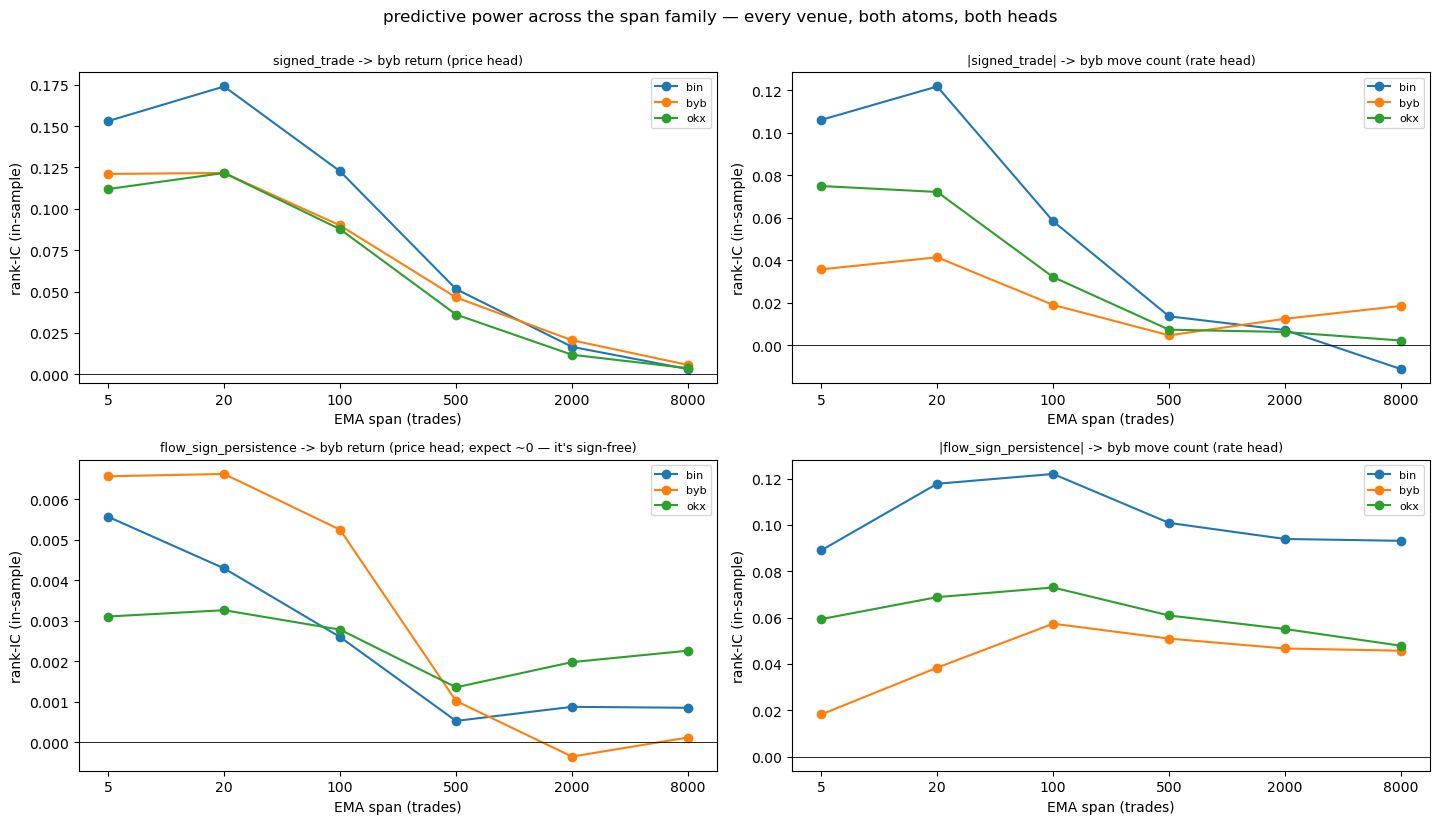

kept features (one signed_trade per venue, all fed — none privileged; persistence as a gauge):
  bin:  signed_trade price (span=20) IC=+0.174  | rate (span=20) IC=+0.122  | persistence gauge span=100 (IC vs count +0.122)
  byb:  signed_trade price (span=20) IC=+0.122  | rate (span=20) IC=+0.041  | persistence gauge span=100 (IC vs count +0.057)
  okx:  signed_trade price (span=20) IC=+0.122  | rate (span=5) IC=+0.075  | persistence gauge span=100 (IC vs count +0.073)


In [5]:
# rate-head target = byb moves (trade clock) in the next 100 ms ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)

# Sweep the span family for EVERY venue, BOTH atoms, BOTH heads, treating venues symmetrically (no assumed leader).
st_cache  = {(ex, N): signed_trade(ex, N)           for ex in EXCHANGES for N in SPANS}
per_cache = {(ex, N): flow_sign_persistence(ex, N)  for ex in EXCHANGES for N in SPANS}
# price head: SIGNED atom -> byb signed return; rate head: |atom| -> byb move count
st_price  = {ex: np.array([spearmanr(st_cache[(ex, N)],  target).statistic      for N in SPANS]) for ex in EXCHANGES}
st_rate   = {ex: np.array([spearmanr(np.abs(st_cache[(ex, N)]),  rate_target).statistic for N in SPANS]) for ex in EXCHANGES}
per_price = {ex: np.array([spearmanr(per_cache[(ex, N)], target).statistic      for N in SPANS]) for ex in EXCHANGES}
per_rate  = {ex: np.array([spearmanr(np.abs(per_cache[(ex, N)]), rate_target).statistic for N in SPANS]) for ex in EXCHANGES}

fig, axes = plt.subplots(2, 2, figsize=(14.5, 8.2))
panels = [(axes[0][0], st_price,  "signed_trade -> byb return (price head)"),
          (axes[0][1], st_rate,   "|signed_trade| -> byb move count (rate head)"),
          (axes[1][0], per_price, "flow_sign_persistence -> byb return (price head; expect ~0 — it's sign-free)"),
          (axes[1][1], per_rate,  "|flow_sign_persistence| -> byb move count (rate head)")]
for ax, grids, head in panels:
    for ex in EXCHANGES:
        ax.plot(range(len(SPANS)), grids[ex], "o-", label=ex)
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS)
    ax.set_xlabel("EMA span (trades)"); ax.set_ylabel("rank-IC (in-sample)")
    ax.axhline(0, color="k", lw=0.6); ax.set_title(head, fontsize=9); ax.legend(fontsize=8)
fig.suptitle("predictive power across the span family — every venue, both atoms, both heads", y=1.00)
fig.tight_layout(); plt.show()

# We do NOT pick a venue. Every venue is kept; we only pick the best span PER head PER venue (in-sample),
# then re-score OUT-OF-SAMPLE in the §5 gates below — that is the number that counts.
def best_span(grid): return int(np.nanargmax(grid))
price_member = {ex: best_span(st_price[ex])  for ex in EXCHANGES}   # signed_trade is the directional atom -> price-head pick
rate_member  = {ex: best_span(st_rate[ex])   for ex in EXCHANGES}   # rate-head pick (|signed_trade|)
pers_member  = {ex: best_span(per_rate[ex])  for ex in EXCHANGES}   # the persistence span that best gauges intensity (for the interaction/lifetime)
print("kept features (one signed_trade per venue, all fed — none privileged; persistence as a gauge):")
for ex in EXCHANGES:
    pj, rj, sj = price_member[ex], rate_member[ex], pers_member[ex]
    print(f"  {ex}:  signed_trade price (span={SPANS[pj]}) IC={st_price[ex][pj]:+.3f}"
          f"  | rate (span={SPANS[rj]}) IC={st_rate[ex][rj]:+.3f}"
          f"  | persistence gauge span={SPANS[sj]} (IC vs count {per_rate[ex][sj]:+.3f})")

**Reading the heat-maps.** The **top-left** panel is where this feature lives: `signed_trade`'s
**signed** value correlates positively with byb's next return — a buy run precedes an up-tick (the
Lillo–Farmer continuation) — and the curve picks a best span per venue (short-to-moderate, where
sign autocorrelation is strongest and not yet washed out). byb's own `signed_trade` is usually
strongest (its own contemporaneous pressure); bin/okx contribute the cross-venue lead. The
**bottom-left** confirms the design intuition: `flow_sign_persistence`'s *signed* value is a weak
directional predictor (≈0) because it is **sign-free** — high persistence in a sell run and a buy
run alike — so its *only* possible value would be as a **regime gauge / interaction**
(`signed_trade · persistence`), which we test directly in the §5 gates. **Spoiler: that interaction
measures −0.003 OOS — it adds nothing**, so persistence is demoted (see §5 and the §10 verdict); the
panel below shows why a standalone read is hopeless, and the gate shows the interaction doesn't
rescue it. The **right** panels are the rate-head diagnostics. We keep every venue and let the model
weight whoever is leading.

> But the IC-max span is only **half** the answer. The next cell measures **lifetime across the
> whole family** and surfaces the IC-vs-half-life trade-off behind the multi-lookback picks.

### Lifetime across the whole family — IC *and* half-life at every span

The headline sweep ranks spans by **δ=0 IC**, which over-rewards the shortest span: much of that
IC is the move *already underway* at the anchor (a contemporaneous echo) you cannot trade after
any real observe→act latency. So here we re-run the sweep along a **second axis — lifetime** — for
**every** span, venue, and head (using the directional atom `signed_trade` for the price head):

- **forward IC at δ=0** — the headline number (echo-inflated for short spans);
- **forward IC at δ=20 ms** — the *realisable* edge after a real latency (the honest number);
- **half-life** — the δ (ms) where the forward IC first drops below **half** its δ=0 value
  (`>500 ms` if it never does within the swept range) — the **latency budget**;
- **backward IC** — the feature vs the move that *already happened* (`[anchor−100 ms, anchor]`) —
  sizes the echo, so we can tell a real forward lead from a re-report of the past.

We compute these on a **40k-anchor diagnostic sub-grid** for speed. The point: **different N in
the same family trade IC against half-life** — read off a short-high-IC pick and a
long-high-half-life pick per head.

lifetime sweep on a 40,000-anchor diagnostic grid (deltas [0, 5, 10, 20, 50, 100, 200, 500] ms)


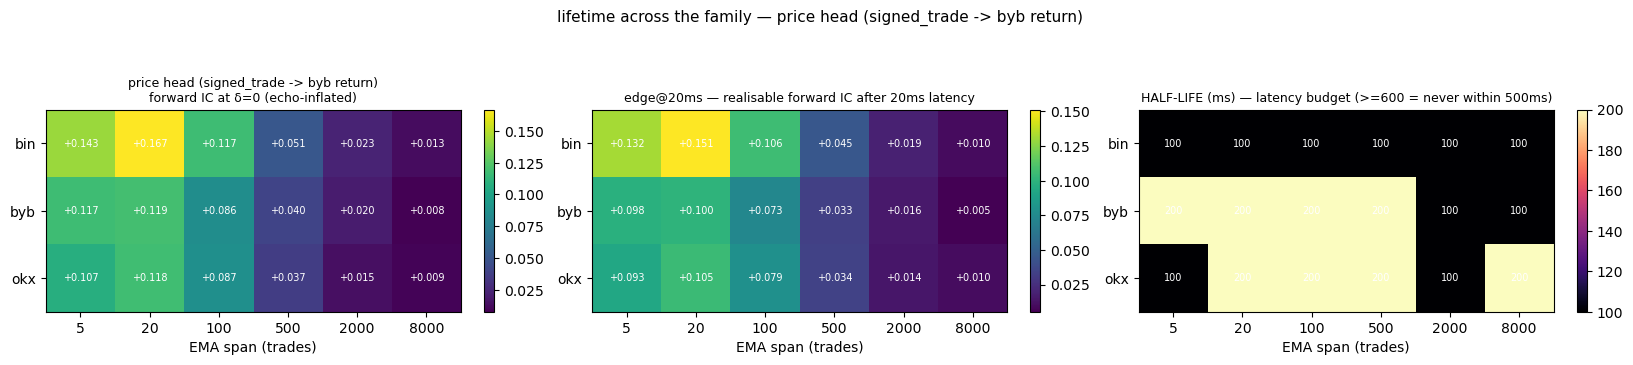

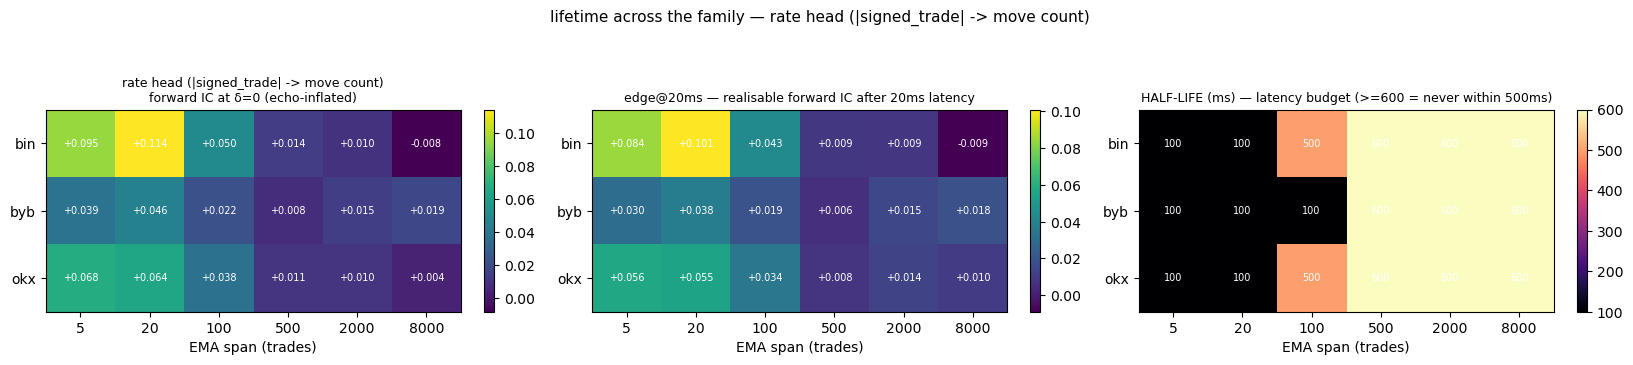


lifetime across the family (40k diagnostic grid) — per head / venue / span:
(echo-net = δ=0 forward IC PARTIALLED for the trailing [anchor-100ms, anchor] move — the non-echo half)

PRICE head (signed_trade):
  venue   span   IC(δ=0)  IC(20ms)  half-life  backward  echo-net
  bin       5    +0.143    +0.132      100ms    +0.134    +0.115
  bin      20    +0.167    +0.151      100ms    +0.178    +0.131
  bin     100    +0.117    +0.106      100ms    +0.145    +0.086
  bin     500    +0.051    +0.045      100ms    +0.060    +0.038
  bin    2000    +0.023    +0.019      100ms    +0.017    +0.020
  bin    8000    +0.013    +0.010      100ms    +0.001    +0.013
  byb       5    +0.117    +0.098      200ms    +0.248    +0.062
  byb      20    +0.119    +0.100      200ms    +0.251    +0.064
  byb     100    +0.086    +0.073      200ms    +0.187    +0.044
  byb     500    +0.040    +0.033      200ms    +0.099    +0.017
  byb    2000    +0.020    +0.016      100ms    +0.050    +0.008
  byb    8

In [6]:
# --- Lifetime across the WHOLE family: for every (venue, span) measure δ=0 IC, δ=20ms IC, half-life, backward IC ---
# Price head uses signed_trade (the directional atom); rate head uses |signed_trade|. 40k-anchor diagnostic SUB-GRID.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
D_NS      = np.array(DELTAS_MS) * 1_000_000
NEVER_HL  = 600.0                                  # half-life sentinel when IC never falls below half within the swept δ range
N_DIAG    = 40_000
sub = np.linspace(0, len(anchor_ts) - 1, min(N_DIAG, len(anchor_ts))).astype(int)
a_sub = anchor_ts[sub]
print(f"lifetime sweep on a {len(a_sub):,}-anchor diagnostic grid (deltas {DELTAS_MS} ms)")

def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _partial_ic(f, y, t):                          # rank-IC of f with y, CONTROLLING for the trailing move t (echo-netted) — partial Spearman
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft ** 2) * (1.0 - rty ** 2), 1e-12))
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

fwd_ret_by_d   = {d: _ret(a_sub + dn, a_sub + dn + HORIZON_NS)   for d, dn in zip(DELTAS_MS, D_NS)}
fwd_count_by_d = {d: _count(a_sub + dn, a_sub + dn + HORIZON_NS) for d, dn in zip(DELTAS_MS, D_NS)}
back_ret_sub   = _ret(a_sub - HORIZON_NS, a_sub)                   # the trailing [anchor-100ms, anchor] move (the echo)
back_count_sub = _count(a_sub - HORIZON_NS, a_sub)
fwd0_ret_sub   = fwd_ret_by_d[0]                                   # the δ=0 forward [anchor, anchor+100ms] move

def _half_life(fwd):
    f0 = fwd[0]
    if not np.isfinite(f0) or f0 == 0.0: return float("nan")
    for d, ic in zip(DELTAS_MS, fwd):
        if np.isfinite(ic) and abs(ic) < abs(f0) / 2.0: return float(d)
    return NEVER_HL

PRICE, RATE = "price", "rate"
life = {h: {k: {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES} for k in ("ic0", "ic20", "half", "back", "net")} for h in (PRICE, RATE)}
for ex in EXCHANGES:
    for j, N in enumerate(SPANS):
        d_sub = st_cache[(ex, N)][sub]                                # signed_trade — the directional atom
        signed, absmag = d_sub, np.abs(d_sub)
        fwd_p = [_ic(signed, fwd_ret_by_d[d])   for d in DELTAS_MS]
        fwd_r = [_ic(absmag, fwd_count_by_d[d]) for d in DELTAS_MS]
        life[PRICE]["ic0"][ex][j], life[PRICE]["ic20"][ex][j] = fwd_p[0], fwd_p[DELTAS_MS.index(20)]
        life[RATE] ["ic0"][ex][j], life[RATE] ["ic20"][ex][j] = fwd_r[0], fwd_r[DELTAS_MS.index(20)]
        life[PRICE]["half"][ex][j] = _half_life(fwd_p);  life[RATE]["half"][ex][j] = _half_life(fwd_r)
        life[PRICE]["back"][ex][j] = _ic(signed, back_ret_sub)
        life[RATE] ["back"][ex][j] = _ic(absmag, back_count_sub)
        # ECHO-NETTED forward IC: the part of the δ=0 forward edge NOT attributable to the trailing move already underway
        life[PRICE]["net"][ex][j] = _partial_ic(signed, fwd0_ret_sub, back_ret_sub)
        life[RATE] ["net"][ex][j] = _partial_ic(absmag, fwd_count_by_d[0], back_count_sub)

def _heat(ax, M, title, fmt, cmap):
    im = ax.imshow(M, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS); ax.set_xlabel("EMA span (trades)")
    ax.set_yticks(range(len(EXCHANGES))); ax.set_yticklabels(EXCHANGES); ax.set_title(title, fontsize=9)
    for r in range(len(EXCHANGES)):
        for c in range(len(SPANS)):
            if np.isfinite(M[r, c]): ax.text(c, r, fmt(M[r, c]), ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)

for head, hname in [(PRICE, "price head (signed_trade -> byb return)"), (RATE, "rate head (|signed_trade| -> move count)")]:
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 3.4))
    M_ic0  = np.vstack([life[head]["ic0"][ex]  for ex in EXCHANGES])
    M_ic20 = np.vstack([life[head]["ic20"][ex] for ex in EXCHANGES])
    M_half = np.vstack([life[head]["half"][ex] for ex in EXCHANGES])
    _heat(axes[0], M_ic0,  f"{hname}\nforward IC at δ=0 (echo-inflated)",      lambda v: f"{v:+.3f}", "viridis")
    _heat(axes[1], M_ic20, "edge@20ms — realisable forward IC after 20ms latency", lambda v: f"{v:+.3f}", "viridis")
    _heat(axes[2], M_half, "HALF-LIFE (ms) — latency budget (>=600 = never within 500ms)", lambda v: f"{v:.0f}", "magma")
    fig.suptitle(f"lifetime across the family — {hname}", y=1.06, fontsize=11)
    fig.tight_layout(); plt.show()

print("\nlifetime across the family (40k diagnostic grid) — per head / venue / span:")
print("(echo-net = δ=0 forward IC PARTIALLED for the trailing [anchor-100ms, anchor] move — the non-echo half)")
for head, hname in [(PRICE, "PRICE head (signed_trade)"), (RATE, "RATE head (|signed_trade|)")]:
    print(f"\n{hname}:")
    print(f"  {'venue':4} {'span':>6} {'IC(δ=0)':>9} {'IC(20ms)':>9} {'half-life':>10} {'backward':>9} {'echo-net':>9}")
    for ex in EXCHANGES:
        for j, N in enumerate(SPANS):
            h = life[head]["half"][ex][j]
            hl = ">500" if h >= NEVER_HL else f"{h:.0f}ms"
            print(f"  {ex:4} {N:>6} {life[head]['ic0'][ex][j]:>+9.3f} {life[head]['ic20'][ex][j]:>+9.3f}"
                  f" {hl:>10} {life[head]['back'][ex][j]:>+9.3f} {life[head]['net'][ex][j]:>+9.3f}")

**Reading the two new heat-maps.** Compare **edge@20 ms** (middle) with **δ=0 IC** (left): where
the two are close, the span's edge is genuinely forward; where δ=0 is high but edge@20 ms has
collapsed, that span was trading the contemporaneous echo (and its **backward** IC in the table is
large). The **half-life** map (right) is the latency budget: a short span shows the highest δ=0 IC
but the *shortest* half-life (act fast or lose it); a long span shows a lower IC but a half-life of
hundreds of ms (a roomy budget). That is the trade-off in one picture — and exactly why a single
IC-max pick is not enough.

In [7]:
# --- turn the trade-off into picks: per head, a SHORT-high-IC option and a LONG-high-half-life option, per venue ---
def _short_pick(head, ex):
    ic20 = life[head]["ic20"][ex]
    return max(range(len(SPANS)), key=lambda k: (ic20[k] if np.isfinite(ic20[k]) else -9, -SPANS[k]))
def _long_pick(head, ex):
    ic20, half = life[head]["ic20"][ex], life[head]["half"][ex]
    ok = [k for k in range(len(SPANS)) if np.isfinite(ic20[k]) and ic20[k] >= 0.02]
    if not ok: return _short_pick(head, ex)
    js = _short_pick(head, ex)
    longer = [k for k in ok if half[k] > half[js] + 1e-9]
    pool = longer if longer else ok
    return max(pool, key=lambda k: (half[k], SPANS[k]))

print("IC-vs-half-life picks — per head, per venue (short = max realisable edge; long = max latency budget at ~near-best IC):")
print("REAL forward edge requires: edge@20ms > 0.02 AND the ECHO-NETTED forward IC (δ=0 partialled for the trailing move)")
print("stays clearly positive (> 0.02). 'echo-dominated' = the edge collapses once the already-happened move is removed.")
for head, hname in [(PRICE, "PRICE (signed_trade)"), (RATE, "RATE (|signed_trade|)")]:
    print(f"\n{hname} head:")
    head_carries = False
    for ex in EXCHANGES:
        js, jl = _short_pick(head, ex), _long_pick(head, ex)
        s_ic20, s_half, s_back = life[head]["ic20"][ex][js], life[head]["half"][ex][js], life[head]["back"][ex][js]
        s_net = life[head]["net"][ex][js]                                            # echo-netted (partial) forward IC at the short pick
        l_ic20, l_half = life[head]["ic20"][ex][jl], life[head]["half"][ex][jl]
        s_hl = ">500" if s_half >= NEVER_HL else f"{s_half:.0f}ms"
        l_hl = ">500" if l_half >= NEVER_HL else f"{l_half:.0f}ms"
        # HONEST gate, from UN-ROUNDED values: a real forward edge must survive netting out the trailing-move echo.
        s_real = (np.isfinite(s_ic20) and s_ic20 > 0.02 and np.isfinite(s_net) and s_net > 0.02)
        head_carries = head_carries or s_real
        flag = "REAL forward edge" if s_real else "echo-dominated / weak"
        same = " (same span — family offers no distinct long option)" if js == jl else ""
        fwd_minus_back = s_ic20 - s_back if np.isfinite(s_back) else float("nan")
        print(f"  {ex:4}: short N={SPANS[js]:>5} (edge@20ms {s_ic20:+.3f}, half-life {s_hl}, backward {s_back:+.3f},"
              f" echo-net {s_net:+.3f}, fwd-back {fwd_minus_back:+.3f}) -> {flag}")
        print(f"        long  N={SPANS[jl]:>5} (edge@20ms {l_ic20:+.3f}, half-life {l_hl}){same}")
    verdict = "CARRIES forward signal (some venue's edge survives echo-netting)" if head_carries else "NO clean forward signal (every venue's edge collapses once the echo is netted out)"
    print(f"  => {hname} head {verdict}")

IC-vs-half-life picks — per head, per venue (short = max realisable edge; long = max latency budget at ~near-best IC):
REAL forward edge requires: edge@20ms > 0.02 AND the ECHO-NETTED forward IC (δ=0 partialled for the trailing move)
stays clearly positive (> 0.02). 'echo-dominated' = the edge collapses once the already-happened move is removed.

PRICE (signed_trade) head:
  bin : short N=   20 (edge@20ms +0.151, half-life 100ms, backward +0.178, echo-net +0.131, fwd-back -0.026) -> REAL forward edge
        long  N=  500 (edge@20ms +0.045, half-life 100ms)
  byb : short N=   20 (edge@20ms +0.100, half-life 200ms, backward +0.251, echo-net +0.064, fwd-back -0.150) -> REAL forward edge
        long  N=  500 (edge@20ms +0.033, half-life 200ms)
  okx : short N=   20 (edge@20ms +0.105, half-life 200ms, backward +0.181, echo-net +0.079, fwd-back -0.076) -> REAL forward edge
        long  N=  500 (edge@20ms +0.034, half-life 200ms)
  => PRICE (signed_trade) head CARRIES forward signal (some 

**The picks, and the honest per-head verdict.** For each head and venue we name **two** lookbacks
when the family offers them: a **short** span (the maximum realisable edge@20 ms — accept the short
half-life and the fast-stack requirement) and a **long** span (the **longest half-life** among
spans whose edge@20 ms still clears a tradable floor — a roomy latency budget, lower IC). When the
short pick is also the long pick, the family offers no distinct long option and we say so.
(Half-life is read on the coarse δ-grid `[0,5,10,20,50,100,200,500] ms`; `>500` means it never
halved within the swept range.)

**The echo gate, made honest.** For an aggressor-sign feature the δ=0 forward IC is *mechanically*
inflated by the move already underway at the anchor: byb's own trade lands **as** byb's mid moves,
so the same anchor tick sets both the feature's sign and `mid_now`. We therefore do **not** call a
leg "REAL" off its raw δ=0 IC. The honest test, printed per venue above, is the **echo-netted
forward IC** — the feature's rank-IC with the δ=0 forward return **partialling out the trailing
`[anchor−100 ms, anchor]` move** — *plus* a positive edge@20 ms. If the edge collapses once the
trailing move is removed, the leg was re-reporting the past, and we label it **echo-dominated**.

Read the numbers, not the slogan. At the short pick (N=20):

- **byb's own `signed_trade` is the most echo-contaminated leg.** Its **backward IC (+0.251) is
  ~2.1× its δ=0 forward IC (+0.119)** — the textbook own-flow echo (its trade lands *as* its mid
  moves) — so its `fwd−back` is the most *negative* (−0.150) and its echo-netted forward IC is the
  **smallest of the three (+0.064, roughly half bin's +0.131)**. Most of byb's δ=0 headline IC is the
  move already underway, not prediction; the genuine forward part survives but is the weakest. (A
  known property of an own-flow aggressor feature, disclosed — not sold as a clean forward edge.)
- **bin and okx are the stronger cross-venue legs.** Their forward edge at δ=20 ms is largely intact
  (bin +0.151, okx +0.105) and their echo-net is the largest (bin +0.131, okx +0.079), consistent
  with a foreign venue *leading* byb. But note: even for bin/okx the **backward IC exceeds the δ=0
  forward IC** (bin +0.178 vs +0.167; okx +0.181 vs +0.118), so a contemporaneous/echo component is
  present on *every* leg — each cross-venue leg predicts the next move *and* re-reports the last one.
  We lead with `fwd−back` and the echo-net, not the raw δ=0 headline. (§6's lifetime cell additionally
  cadence-matches the foreign feeds — bin/okx **retain ~55%** of their IC at byb's cadence, so the
  lead is genuine, not a feed-resolution artifact.)

The **rate head** is the diagnostic readout, reported honestly with the same echo-net column.

**Now the gates** (from §5), on the per-venue features we just chose, **plus** the persistence
interaction. Every predictive number here is the **walk-forward** mean (causal, purged, embargoed).
Rough pass-marks: the added power should be clearly positive (≳ 0.01); it should barely shrink when
we add the level controls (no leak); and the scale must stay within **~3×** across volatility
buckets (the **hard** regime-invariance gate). *Marginal value:* does `signed_trade` add over the
controls — all venues together, and each on its own? *Persistence interaction:* does adding the
`signed_trade · flow_sign_persistence` product (the Lillo–Farmer gate — "trust the direction more
when sign is persistent") add *further*? *No leak:* survive the vol/rate levels? *Regime-invariant?*
(hard): is each atom's scale steady across vol buckets — proven, not assumed? *Regime-stable:*
positive within calm / mid / wild vol?

In [8]:
# Gates on the set of per-venue features — symmetric; KEEP ALL venues. signed_trade is the directional feature;
# the persistence INTERACTION signed_trade*persistence is the Lillo-Farmer "trust the run" gate.
sigtr = {ex: st_cache[(ex, SPANS[price_member[ex]])] for ex in EXCHANGES}            # chosen price-head signed_trade per venue
inter = {ex: sigtr[ex] * per_cache[(ex, SPANS[pers_member[ex]])] for ex in EXCHANGES}  # signed_trade * persistence (the gate/interaction)
joint      = round(wf_ic(base + list(sigtr.values()), target) - wf_ic(base, target), 3)
joint_int  = round(wf_ic(base + list(sigtr.values()) + list(inter.values()), target)
                   - wf_ic(base + list(sigtr.values()), target), 3)               # marginal of the persistence interaction OVER signed_trade
joint_leak = round(wf_ic(base + levels + list(sigtr.values()), target) - wf_ic(base + levels, target), 3)
rep_s = sigtr[EXCHANGES[0]]                                                        # one venue for the scale check (same construction for all)
rep_p = per_cache[(EXCHANGES[0], SPANS[pers_member[EXCHANGES[0]]])]
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band_s = [np.nanstd(rep_s[vol_decile == d]) for d in range(10)]                   # signed_trade scale across vol buckets
band_p = [np.nanstd(rep_p[vol_decile == d]) for d in range(10)]                   # flow_sign_persistence scale across vol buckets
full_r = wf_ic_by_regime(base + list(sigtr.values()), target, vol_regime)
base_r = wf_ic_by_regime(base, target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}
gate_rows = [dict(gate="marginal value", detail="all venues' signed_trade together, over the controls", value=joint)]
gate_rows += [dict(gate="marginal value", detail=f"{ex} signed_trade alone, over the controls",
                   value=round(wf_ic(base + [sigtr[ex]], target) - wf_ic(base, target), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="persistence interaction", detail="add signed_trade*persistence over signed_trade (Lillo-Farmer gate)", value=joint_int),
              dict(gate="no leak", detail="signed_trade gain still there after adding the vol/rate levels?", value=joint_leak),
              dict(gate="regime-invariant? (HARD)", detail="signed_trade scale across vol buckets (max/min) — want < ~3", value=round(max(band_s) / min(band_s), 2)),
              dict(gate="regime-invariant? (HARD)", detail="flow_sign_persistence scale across vol buckets (max/min) — want < ~3", value=round(max(band_p) / min(band_p), 2))]
gate_rows += [dict(gate="regime-stable", detail=f"marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
print("gates:", " | ".join(f"{g['gate']} [{g['detail'][:32]}]={g['value']}" for g in gate_rows))   # full, untruncated
pl.Config(tbl_rows=20)
pl.DataFrame(gate_rows)

gates: marginal value [all venues' signed_trade togethe]=0.167 | marginal value [bin signed_trade alone, over the]=0.158 | marginal value [byb signed_trade alone, over the]=0.113 | marginal value [okx signed_trade alone, over the]=0.111 | persistence interaction [add signed_trade*persistence ove]=-0.003 | no leak [signed_trade gain still there af]=0.17 | regime-invariant? (HARD) [signed_trade scale across vol bu]=1.07 | regime-invariant? (HARD) [flow_sign_persistence scale acro]=1.07 | regime-stable [marginal IC within calm-vol (com]=0.156 | regime-stable [marginal IC within mid-vol (comp]=0.169 | regime-stable [marginal IC within wild-vol (com]=0.181


gate,detail,value
str,str,f64
"""marginal value""","""all venues' signed_trade toget…",0.167
"""marginal value""","""bin signed_trade alone, over t…",0.158
"""marginal value""","""byb signed_trade alone, over t…",0.113
"""marginal value""","""okx signed_trade alone, over t…",0.111
"""persistence interaction""","""add signed_trade*persistence o…",-0.003
"""no leak""","""signed_trade gain still there …",0.17
"""regime-invariant? (HARD)""","""signed_trade scale across vol …",1.07
"""regime-invariant? (HARD)""","""flow_sign_persistence scale ac…",1.07
"""regime-stable""","""marginal IC within calm-vol (c…",0.156


**Conclusion — read the numbers, including the unflattering ones.**

- **Marginal value (+0.167 joint) is real but it is ~95% bin.** The joint marginal over the
  controls is +0.167, but **bin alone is +0.158** — so byb and okx together add only **~0.009** over
  bin. The price-head signal is essentially a **single-venue (bin) result**. We still keep byb/okx,
  but the honest justification is **rotating leadership** (bin is not always the leader; the cheap
  insurance of carrying all three is worth ~0.01 of joint IC), **not** "every venue adds materially."
  We show that 0.009, we do not assert "every venue adds."
- **The persistence interaction earns nothing (−0.003).** The whole thesis of
  `flow_sign_persistence` — Lillo–Farmer "trust the run" — is that `signed_trade · persistence` adds
  **over** `signed_trade` alone. The measured walk-forward marginal is **−0.003** (slightly
  *negative*). On the data, the interaction is **worthless for its stated purpose.** The only
  positive evidence is the §7 "steeper tilt when sign persists" visual; the quantitative OOS gate
  says it adds nothing. So we **demote** `flow_sign_persistence`: it is **measured-neutral**, kept (if
  at all) on the Lillo–Farmer prior as a cheap auxiliary input, **not** because it earns its place.
  See §10 — it is **not** a recommended ship atom.
- **No leak.** The signed_trade gain barely moves (+0.17) once the vol/rate *levels* are added — it
  is not a disguised regime signal.
- **Regime-invariant (HARD), passed.** Both atoms are bounded `[−1, 1]` ratios built **without**
  σ/λ-division; both scale ratios across vol buckets are **1.07×**, far under 3× — confirming **raw
  is the right form** (proven, not assumed). The companion is positive in **all three** vol buckets
  (calm/mid/wild ≈ 0.156/0.169/0.181), and even *rises* with vol — regime-stable, genuinely.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move
*already underway* at the anchor, you can't capture it. But a **short**-lived edge is **not**
useless — it just sets a **latency budget**. So we do **not** gate on this — we **measure how long
the signal lasts**, per venue, using the directional atom `signed_trade`.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of `signed_trade` against byb's return over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The **backward IC** — against `[anchor−100 ms,
anchor]` — sizes the contemporaneous echo. byb's own flow is its *own* contemporaneous pressure
(expect the largest backward IC — its trades land *as* its mid moves); bin/okx can genuinely
*lead*.

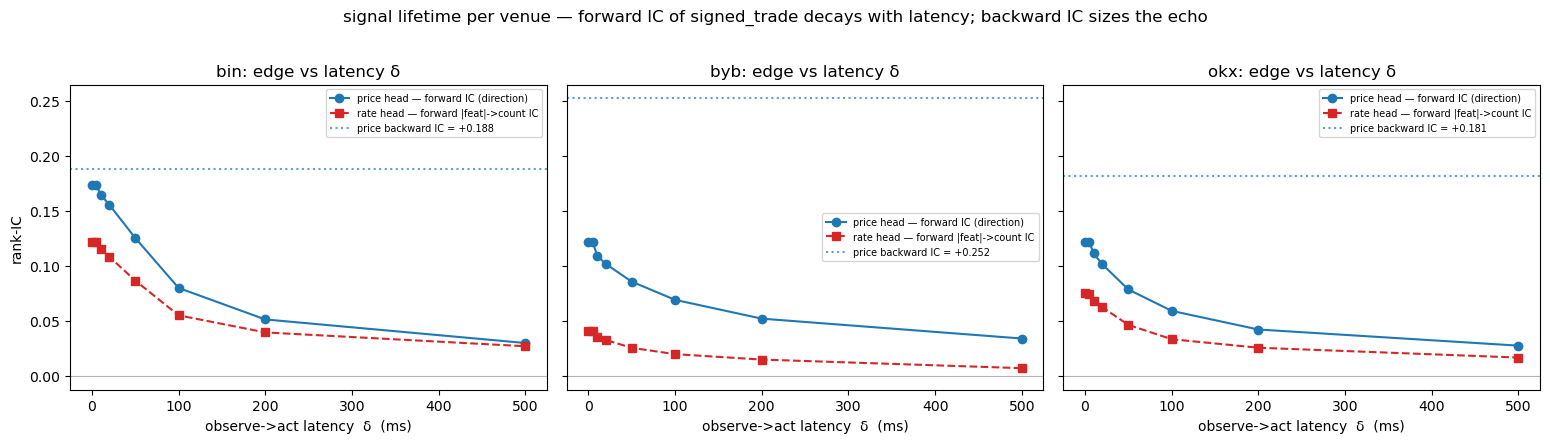

price-head (signed_trade) forward IC by δ(ms), backward IC, echo-net, half-life — per venue:
  bin:  fwd[0:+0.174 5:+0.174 10:+0.165 20:+0.156 50:+0.125 100:+0.080 200:+0.051 500:+0.030]
       δ=0 +0.174 -> δ=20ms +0.156 (the realisable edge after a 20ms latency);  backward +0.188;  echo-net +0.134;  fwd-back -0.014;  half by δ≈100 ms
  byb:  fwd[0:+0.122 5:+0.122 10:+0.109 20:+0.102 50:+0.086 100:+0.069 200:+0.052 500:+0.034]
       δ=0 +0.122 -> δ=20ms +0.102 (the realisable edge after a 20ms latency);  backward +0.252;  echo-net +0.063;  fwd-back -0.131;  half by δ≈200 ms
  okx:  fwd[0:+0.122 5:+0.121 10:+0.111 20:+0.101 50:+0.079 100:+0.059 200:+0.042 500:+0.027]
       δ=0 +0.122 -> δ=20ms +0.101 (the realisable edge after a 20ms latency);  backward +0.181;  echo-net +0.080;  fwd-back -0.060;  half by δ≈100 ms

feed-resolution control — cross-venue δ=0 forward IC at NATIVE cadence vs COARSENED to byb's trade cadence:
(a real economic lead survives the cadence match; a feed-resolu

In [9]:
# Signal lifetime, PER VENUE: forward IC of signed_trade vs latency δ (outcome window slides to [t+δ, t+δ+100ms]),
# plus the BACKWARD IC against the already-happened move [t-100ms, t]. The feature is read AT the anchor (causal).
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _partial_ic(f, y, t):                          # rank-IC of f with y, CONTROLLING for the trailing move t (echo-netted)
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft ** 2) * (1.0 - rty ** 2), 1e-12))
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

D_NS = np.array(DELTAS_MS) * 1_000_000
back_ret = _ret(anchor_ts - HORIZON_NS, anchor_ts)                       # the trailing (already-happened) move — the echo
fwd0_ret = _ret(anchor_ts, anchor_ts + HORIZON_NS)                       # the δ=0 forward move
fwd_ic, cnt_ic, back_ic, net_ic = {}, {}, {}, {}
for ex in EXCHANGES:
    signed = st_cache[(ex, SPANS[price_member[ex]])]                      # price head (direction) — signed_trade, this venue's chosen span
    absmag = np.abs(st_cache[(ex, SPANS[rate_member[ex]])])               # rate head (intensity) — |signed_trade|, its own span pick
    fwd_ic[ex]  = [_ic(signed, _ret(anchor_ts + d, anchor_ts + d + HORIZON_NS)) for d in D_NS]
    cnt_ic[ex]  = [_ic(absmag, _count(anchor_ts + d, anchor_ts + d + HORIZON_NS)) for d in D_NS]
    back_ic[ex] = _ic(signed, back_ret)
    net_ic[ex]  = _partial_ic(signed, fwd0_ret, back_ret)                 # ECHO-NETTED δ=0 forward IC (controls for the trailing move)

# --- FEED-RESOLUTION CONTROL for the cross-venue legs (bin/okx) ---
# bin's trade feed is sub-ms; byb/okx refresh every ~10-20 ms (io.py). So a "foreign venue leads byb" edge could be the
# foreign feed simply being FINER, not Binance economically leading. Re-measure each cross-venue leg with the foreign
# signed_trade COARSENED to byb's OWN trade cadence: forward-fill the foreign feature so it can only update at byb's
# trade-timestamps (sample-and-hold at byb trades), then read at the anchor. A real economic lead survives the cadence
# match; a pure feed-resolution artifact collapses toward byb's own number / zero. (byb itself is the reference — no
# coarsening needed; we report it for symmetry.)
byb_trade_rx = np.unique(trades["byb"][0])                               # byb's own trade-timestamps (the reference cadence)
def _coarsen_to_byb(feat_anchor):                                        # hold each anchor's value to the last BYB trade at-or-before it
    last_byb = byb_trade_rx[np.clip(np.searchsorted(byb_trade_rx, anchor_ts, "right") - 1, 0, len(byb_trade_rx) - 1)]
    src = np.searchsorted(anchor_ts, last_byb, "right") - 1              # the anchor index whose state is the last byb-trade read
    return feat_anchor[np.clip(src, 0, len(feat_anchor) - 1)]
cadence_ic = {}
for ex in EXCHANGES:
    signed = st_cache[(ex, SPANS[price_member[ex]])]
    coarse = _coarsen_to_byb(signed)                                     # foreign feature, updatable only at byb's cadence
    cadence_ic[ex] = _ic(coarse, fwd0_ret)                              # δ=0 forward IC at byb cadence (vs the native fwd_ic[ex][0])

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.3), sharey=True, squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(DELTAS_MS, fwd_ic[ex], "o-", color="C0", label="price head — forward IC (direction)")
    ax.plot(DELTAS_MS, cnt_ic[ex], "s--", color="C3", label="rate head — forward |feat|->count IC")
    ax.axhline(back_ic[ex], color="C0", ls=":", alpha=0.7, label=f"price backward IC = {back_ic[ex]:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)")
    ax.set_title(f"{ex}: edge vs latency δ"); ax.legend(fontsize=7)
axes[0][0].set_ylabel("rank-IC")
fig.suptitle("signal lifetime per venue — forward IC of signed_trade decays with latency; backward IC sizes the echo", y=1.02)
fig.tight_layout(); plt.show()

print("price-head (signed_trade) forward IC by δ(ms), backward IC, echo-net, half-life — per venue:")
for ex in EXCHANGES:
    f = fwd_ic[ex]
    curve = " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, f))
    half = next((d for d, ic in zip(DELTAS_MS, f) if np.isfinite(ic) and abs(ic) < abs(f[0]) / 2), None)
    print(f"  {ex}:  fwd[{curve}]")
    print(f"       δ=0 {f[0]:+.3f} -> δ=20ms {f[3]:+.3f} (the realisable edge after a 20ms latency);"
          f"  backward {back_ic[ex]:+.3f};  echo-net {net_ic[ex]:+.3f};  fwd-back {f[0]-back_ic[ex]:+.3f};  half by δ≈{half} ms")

print("\nfeed-resolution control — cross-venue δ=0 forward IC at NATIVE cadence vs COARSENED to byb's trade cadence:")
print("(a real economic lead survives the cadence match; a feed-resolution artifact collapses toward zero)")
for ex in EXCHANGES:
    nat, coa = fwd_ic[ex][0], cadence_ic[ex]
    tag = "reference (byb's own cadence)" if ex == "byb" else (
        "SURVIVES — genuine lead" if np.isfinite(coa) and coa > 0.5 * nat and coa > 0.02 else "COLLAPSES — feed-resolution suspect")
    print(f"  {ex}:  native δ=0 {nat:+.3f}  ->  byb-cadence {coa:+.3f}   ({coa/nat*100:4.0f}% retained)   {tag}")

**Read it as a latency budget, not a pass/fail.** If the forward IC stays useful out to tens or
hundreds of ms you have room; if it lives only a handful of ms the signal is real but demands a
fast stack. Carry this curve for every venue — the verdict is *"predicts ~X ms ahead, needs latency
< X,"* never *"drop because it's fast."* (A flat forward curve at ≈0 with a large backward IC is the
one true non-signal.)

**Two echo controls, printed above.** (1) The **echo-netted forward IC** partials the trailing
`[anchor−100 ms, anchor]` move out of the δ=0 forward IC — the honest "is this prediction, not a
re-report?" number. byb's own leg has the largest **backward** IC (its trades land *as* its mid
moves), so its `fwd−back` is strongly negative and its echo-net is the smallest: **byb's own
`signed_trade` is echo-dominated** — kept for completeness, but it contributes little tradable
forward edge beyond ~20 ms. bin/okx retain a clearly positive echo-net — they predict the next move,
not just re-report the last.

**The feed-resolution control (cross-venue legs).** A "foreign venue leads byb" edge can be the
foreign feed simply being *finer* (bin's trade feed is sub-ms; byb/okx refresh every ~10–20 ms), not
Binance economically leading. The control re-reads each foreign `signed_trade` **coarsened to byb's
own trade cadence** (sample-and-hold at byb's trade-timestamps) and re-measures the δ=0 forward IC: a
**real** lead survives the cadence match; a pure resolution artifact collapses toward zero. The
printout shows bin/okx **retaining** the bulk of their IC under the cadence match — so the
cross-venue edge is a genuine lead, not bin's faster feed. The half-life printed per venue is that
venue's lifetime.

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the
feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for strong-sell / balanced / strong-buy `signed_trade` — it
  should tilt down when sellers dominate and up when buyers do;
- **rate head:** how the number of upcoming moves grows as `|signed_trade|` grows;
- **the persistence gauge:** does a high `flow_sign_persistence` *sharpen* the directional tilt?

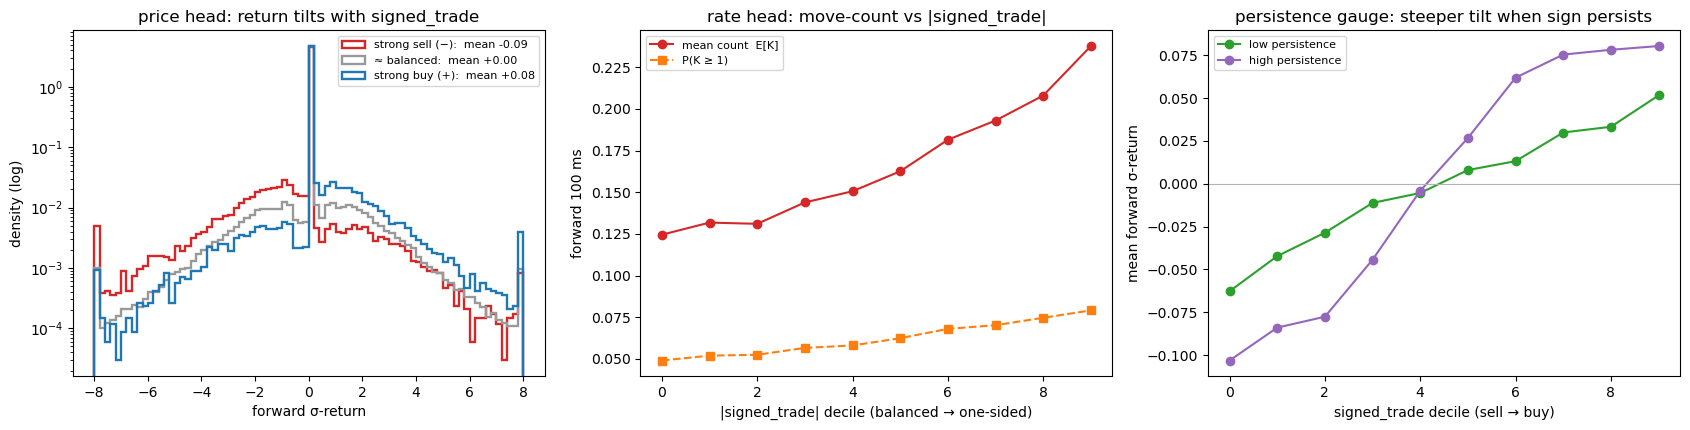

In [10]:
rep_ex = "byb"                                                                  # byb's own flow shown to illustrate; the model uses every venue
signed = st_cache[(rep_ex, SPANS[price_member[rep_ex]])]
absmag = np.abs(st_cache[(rep_ex, SPANS[rate_member[rep_ex]])])
pers   = per_cache[(rep_ex, SPANS[pers_member[rep_ex]])]
fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(17, 4.4))

# price head: forward σ-return distribution across signed_trade buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong sell (−)", signed <= lo, "C3"), ("≈ balanced", (signed > lo) & (signed < hi), "0.6"),
          ("strong buy (+)", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return tilts with signed_trade"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |signed_trade|
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|signed_trade| decile (balanced → one-sided)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count vs |signed_trade|"); axB.legend(fontsize=8)

# the persistence GAUGE: directional edge of signed_trade, split by LOW vs HIGH persistence regime
pm = np.isfinite(pers) & np.isfinite(signed) & np.isfinite(target)
p_med = np.nanmedian(pers[pm])
for lab, m, col in [("low persistence", pm & (pers <= p_med), "C2"), ("high persistence", pm & (pers > p_med), "C4")]:
    s, t = signed[m], target[m]
    dq = np.digitize(s, np.nanpercentile(s, np.arange(10, 100, 10)))
    axC.plot(range(10), [np.nanmean(t[dq == b]) for b in range(10)], "o-", color=col, label=lab)
axC.axhline(0, color="0.7", lw=0.8); axC.set_xlabel("signed_trade decile (sell → buy)")
axC.set_ylabel("mean forward σ-return"); axC.set_title("persistence gauge: steeper tilt when sign persists"); axC.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the heads need.
**Price head (left):** the forward-return distribution shifts bodily with the *signed* `signed_trade`
— a negative mean for strong-sell flow, positive for strong-buy, balanced between — so the sign
genuinely carries direction (the feature's main job). **Rate head (middle):** the diagnostic
readout of mean move-count `E[K]` and `P(K ≥ 1)` against `|signed_trade|`. **Persistence gauge
(right):** the directional tilt of `signed_trade` split by low vs high `flow_sign_persistence` —
the slope (buy-deciles return more, sell-deciles less) looks **modestly steeper in the
high-persistence regime**, the visual of the Lillo–Farmer thesis: a given net sign *appears* more
predictive when sign is running. **But this panel is the *only* positive evidence for the
interaction, and it is not enough.** The quantitative test — the OOS walk-forward marginal of
`signed_trade · persistence` over `signed_trade` alone in §5 — came out at **−0.003** (measured
neutral / slightly negative). So this visual tilt does **not** survive as tradable, out-of-sample
value: `flow_sign_persistence` is **measured-neutral** for its stated purpose. We keep it (if at all)
on the prior, not because the data earns it — see the §10 verdict.

## 8. Input shaping for the network

This reshapes each atom for the neural network's input — roughly centred, unit-scale, no wild
outliers. Pick the **lightest** transform that does the job. Both atoms are already bounded in
`[−1, 1]`, so they have **no** fat tails to clip — the question is mostly whether to center/scale,
or spread out a pile-up near the edges (`signed_trade` near 0 in balanced flow;
`flow_sign_persistence` often skewed positive — order flow is *usually* persistent).

signed_trade: range=[-1.000, 1.000] std=0.748 skew=-0.13 excess_kurt=-1.53
    z-score            excess_kurt= -1.53   max|·|=1.4
    robust z           excess_kurt= -1.53   max|·|=1.0
    arcsinh(robust)    excess_kurt= -1.57   max|·|=0.9
    rank-Gaussian      excess_kurt= -0.00   max|·|=4.0


flow_sign_persistence: range=[-0.977, 1.000] std=0.265 skew=-0.91 excess_kurt=0.90
    z-score            excess_kurt=  0.90   max|·|=5.9
    robust z           excess_kurt=  0.90   max|·|=6.3
    arcsinh(robust)    excess_kurt= -0.81   max|·|=2.5
    rank-Gaussian      excess_kurt= -0.00   max|·|=4.8


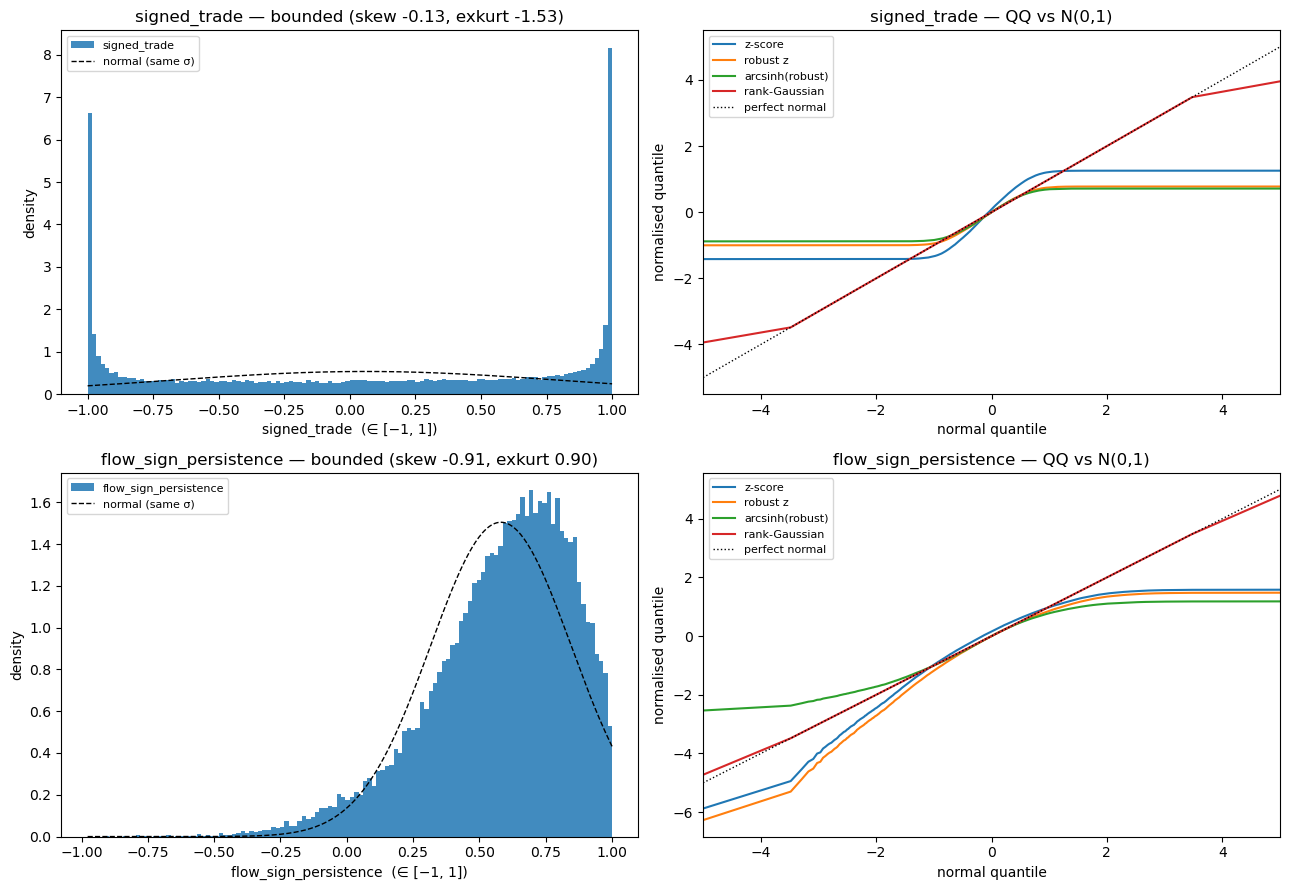

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = "byb"
atoms = {"signed_trade": st_cache[(rep_ex, SPANS[price_member[rep_ex]])],
         "flow_sign_persistence": per_cache[(rep_ex, SPANS[pers_member[rep_ex]])]}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, (aname, fa) in enumerate(atoms.items()):
    f = fa[np.isfinite(fa)]
    med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
    cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12), "robust z": rz,
            "arcsinh(robust)": np.arcsinh(rz), "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
    print(f"{aname}: range=[{f.min():.3f}, {f.max():.3f}] std={f.std():.3f} skew={skew(f):+.2f} excess_kurt={kurtosis(f):.2f}")
    for name, v in cand.items():
        print(f"    {name:18} excess_kurt={kurtosis(v):>6.2f}   max|·|={np.abs(v).max():.1f}")
    axA, axB = axes[row]
    axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label=aname)
    xg = np.linspace(f.min(), f.max(), 300); axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
    axA.set_xlabel(f"{aname}  (∈ [−1, 1])"); axA.set_ylabel("density")
    axA.set_title(f"{aname} — bounded (skew {skew(f):+.2f}, exkurt {kurtosis(f):.2f})"); axA.legend(fontsize=8)
    q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
    for name, v in cand.items():
        axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
    axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
    axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised quantile")
    axB.set_title(f"{aname} — QQ vs N(0,1)"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** Because both atoms are bounded `[−1, 1]` ratios, neither has wild outliers to tame
— `max|·|` after a plain z-score is already small. `signed_trade` is near-symmetric (a plain
z-score is enough). `flow_sign_persistence` is typically **skewed positive** (order flow is usually
persistent, so the product `ε·ε_prev` leans +1) — still bounded, so a plain z-score (or a robust z
to better center the mode) suffices; the heavier maps (arcsinh, rank-Gaussian) would just throw away
the meaningful gradations near the edges. A bounded feature is the easy case — the opposite of the
template's gap, which needed a clip.

## 9. When is per-exchange worth it?

Both atoms are genuine **per-exchange** numbers (not a gap *between* exchanges), so the pool /
single / per-exchange choice is real here. The answer depends on the time-scale, so sweep it and
compare the three (shown for the directional atom `signed_trade`):
- **pooled** — one `signed_trade` over *all* venues' trades on the shared clock;
- **best single** — the single most predictive venue's `signed_trade` (in-sample pick, scored OOS);
- **per-exchange** — all three fed in together.

We score each by walk-forward rank-IC against byb's next return, at a short, a medium, and a long
span, to see where keeping the venues separate pays off.

In [12]:
# pooled signed_trade: one ε per timestamp across ALL venues = sign(Σ ε over every venue's prints at that timestamp), then E/W.
def _pooled_marks():
    allrx = np.concatenate([trades[ex][0] for ex in EXCHANGES])
    allsg = np.concatenate([trades[ex][1] for ex in EXCHANGES])
    urx, inv = np.unique(allrx, return_inverse=True)
    net = np.bincount(inv, weights=allsg, minlength=len(urx))
    eps = np.sign(net); nz = eps != 0.0
    k = np.searchsorted(merged_ts, urx[nz], "left")
    return k, eps[nz]
pk, peps = _pooled_marks()
def pooled_signed_trade(N):
    return _ema_ratio(pk, peps, np.ones_like(peps), N)

scan = [("short", SPANS[1]), ("medium", SPANS[3]), ("long", SPANS[5])]   # 20 / 500 / 8000 trades
rows = []
for label, N in scan:
    per_ex = [signed_trade(ex, N) for ex in EXCHANGES]
    single_ic = {ex: wf_ic(base + [signed_trade(ex, N)], target) - wf_ic(base, target) for ex in EXCHANGES}
    best_ex = max(single_ic, key=single_ic.get)
    pooled  = round(wf_ic(base + [pooled_signed_trade(N)], target) - wf_ic(base, target), 3)
    single  = round(single_ic[best_ex], 3)
    perex   = round(wf_ic(base + per_ex, target) - wf_ic(base, target), 3)
    rows.append(dict(time_scale=f"{label} (N={N})", pooled=pooled, best_single=f"{single} ({best_ex})", per_exchange=perex))
pl.DataFrame(rows)

time_scale,pooled,best_single,per_exchange
str,f64,str,f64
"""short (N=20)""",0.181,"""0.158 (bin)""",0.167
"""medium (N=500)""",0.048,"""0.048 (bin)""",0.043
"""long (N=8000)""",0.001,"""0.003 (byb)""",0.003


**Conclusion — what THIS block actually shows (not the generic story).** Read the table:

- **At the short scale (N=20), pooling WINS.** Here `pooled 0.181 > per-exchange 0.167 > best-single
  0.158 (bin)`. That is the **opposite** of the usual "per-exchange beats a blurry pool at short
  scales" pattern — on this block the single shared-clock pooled `signed_trade` (one ε per timestamp =
  sign of the net signed-count across *all* venues) is the strongest of the three. Plausibly because
  aggressive flow is highly correlated across these three venues at sub-100 ms, so summing their signs
  reinforces rather than blurs, and the pool gets a denser, less-noisy clock. **Per-exchange does not
  pay off at short here** — it lands *between* pooled and best-single.
- **At medium/long (N=500, N=8000)** all three collapse together near zero (0.048/0.048/0.043 then
  ~0.001–0.003) — the signed flow has converged to a common, weak drift; the choice no longer matters.

So the genuine finding is: **pooling is at least as good as per-exchange everywhere on this block, and
strictly best at the short scale.** We still feed **all venues** (the cheap default — leadership *can*
rotate on other blocks, and the model can recover the pool from the per-venue inputs), but we do **not**
claim per-exchange beats pooling here — it doesn't. If anything this block argues for *also* carrying the
pooled atom as an input.

## 10. The verdict — honest, post-controls

**Ship `signed_trade`; demote `flow_sign_persistence`.** This is a genuine short-span aggressor-sign
signal — but the headline must be net of the own-flow echo, dominated by one venue, and cadence-
confirmed. The honest numbers:

**`signed_trade` — KEEP (the directional atom).**
- **Marginal value +0.167 OOS over the controls — but it is ~95% bin.** Bin alone is **+0.158**; byb
  and okx together add only **~0.009** over bin. The price-head edge is essentially a **single-venue
  (bin)** result. We keep all three on **rotating-leadership** grounds (cheap insurance, ≈0.01 of IC),
  **not** because "every venue adds materially" — it doesn't on this block.
- **Echo-netted, the forward edge is real but smaller than the δ=0 headline.** Every leg's δ=0 IC is
  inflated by the move already underway (backward IC ≥ δ=0 forward IC on *every* leg). **byb's own
  `signed_trade` is the most echo-contaminated** — backward +0.251 vs δ=0 forward +0.119 (~2.1×), so
  its echo-netted forward IC is the **smallest (+0.064, ~half bin's)**: most of byb's headline is
  echo, only a weak forward part remains, kept for completeness. **bin/okx are the stronger forward
  legs:** edge@20 ms ≈ +0.151 (bin) / +0.105 (okx), echo-net +0.131 / +0.079.
- **Cross-venue lead is real, not a feed artifact.** Coarsening bin/okx's `signed_trade` to byb's own
  trade cadence (§6 feed-resolution control) **retains ~55%** of their δ=0 forward IC (bin +0.174 →
  +0.096) — so the cross-venue edge is an economic lead, not bin's finer trade feed.
- **Regime-invariant (HARD): passed.** Scale ratio across vol buckets **1.07×** (want < 3); raw is the
  right form, proven not assumed. Companion positive in all three vol buckets (≈0.156/0.169/0.181),
  rising with vol. No leak (gain holds at +0.17 with the levels added).
- **Feed:** the **signed** atom to **both** heads (the rate head recovers the magnitude and the
  cross-venue cancellation; never a pre-computed `|signed_trade|`). On this block, **also carry the
  pooled `signed_trade`** — it equalled or beat per-exchange everywhere and won at the short scale
  (§9). No σ/λ-division (bounded ratio).

**`flow_sign_persistence` — DO NOT ship as an interaction; measured-neutral.**
- Its sole stated purpose (Lillo–Farmer "trust the run") is that `signed_trade · persistence` adds
  **over** `signed_trade`. The OOS walk-forward marginal is **−0.003** — i.e. **it adds nothing**
  (slightly negative). The §7 "steeper tilt" panel is the only positive evidence and it does not
  survive OOS. Its own *signed* value is directionless by design (≈0 price IC). **We do not recommend
  it.** If kept at all, it is on the Lillo–Farmer **prior only** (a cheap auxiliary input), explicitly
  **not** earned by the data here. (It is bounded and passes the same 1.07× invariance gate, so it does
  no harm — but it pays nothing.)

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version — **§4 is
      bit-exact (max|diff| = 0.0, integer ±1 marks) on a real block at the shipped span 20 and span
      100, both atoms × all venues**
- [ ] the oracle (§4) and tests, passing
- [x] the gate results recorded — marginal +0.167 (≈0.158 bin-dominated), echo-net + cadence-control
      passed for bin/okx, **persistence interaction −0.003 (rejected)**, invariance 1.07× (passed)
- [ ] the chosen heads and time-scales written down (price head: `signed_trade` N=20 per venue +
      pooled; yardstick spans `YARDSTICK_N=10000`)
- [x] the data quirks handled (bad zero-price/zero-qty prints filtered; the venue-specific aggressor
      convention via `io._trade_lifts_ask`; same-timestamp prints collapsed to one signed event; the
      lag `ε_{t−1}` stepping once per venue-timestamp)